In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,52,122000,1
1,47,62000,1
2,32,141000,1
3,44,20000,0
4,59,150000,1


In [4]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

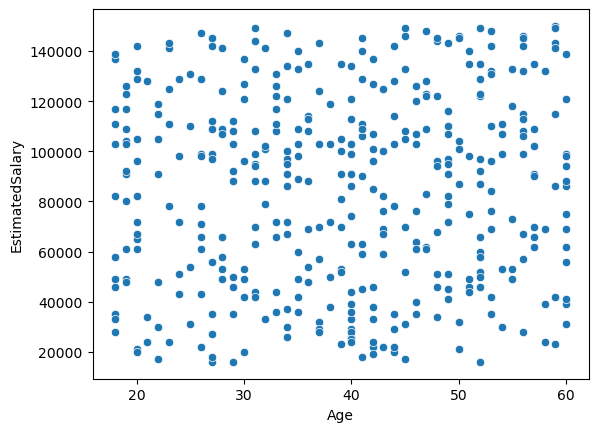

In [6]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])

In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [10]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

C:\Users\avraj\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4437 - loss: 9377.4355 - val_accuracy: 0.3625 - val_loss: 6818.5000
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4437 - loss: 3258.2463 - val_accuracy: 0.6375 - val_loss: 67.3532
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5562 - loss: 838.6868 - val_accuracy: 0.6375 - val_loss: 907.2008
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5562 - loss: 844.8086 - val_accuracy: 0.6375 - val_loss: 169.1398
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4750 - loss: 297.4993 - val_accuracy: 0.6375 - val_loss: 121.9775
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5562 - loss: 203.6073 - val_accuracy: 0.3625 - val_loss: 202.7862
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4563 - loss: 197.0560 - val_accuracy: 0.6375 - val_loss: 142.6298
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 1

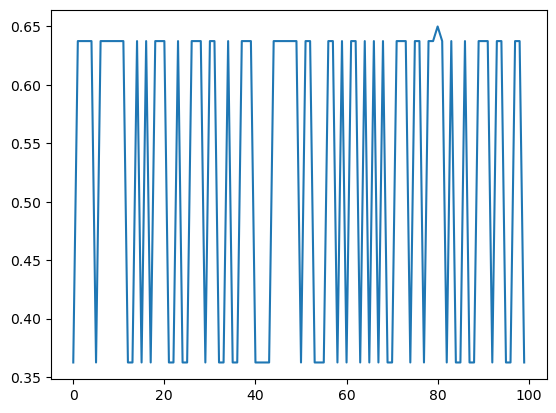

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

In [15]:
# Applying scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[ 1.63268716e+00,  8.38450610e-01],
       [ 7.34428517e-01,  2.74729940e-01],
       [ 4.07789010e-01, -1.71171433e+00],
       [-4.90469635e-01, -4.76897620e-01],
       [ 1.62809379e-01, -1.76540201e+00],
       [ 6.52768641e-01,  1.72429738e+00],
       [-4.08809758e-01,  4.35792988e-01],
       [ 9.79408148e-01,  1.37532744e+00],
       [ 6.52768641e-01,  6.77387561e-01],
       [ 3.26129133e-01, -1.65802664e+00],
       [ 1.30604766e+00,  1.32163976e+00],
       [ 1.63268716e+00,  5.99792082e-02],
       [-4.08809758e-01, -1.44327591e+00],
       [-1.30706840e+00, -1.60433896e+00],
       [ 4.89448887e-01, -8.52711400e-01],
       [ 1.30604766e+00, -2.88990730e-01],
       [ 3.26129133e-01, -2.08459206e-01],
       [ 1.38770753e+00, -1.49696359e+00],
       [ 1.71434704e+00,  1.13666891e-01],
       [ 1.71434704e+00,  2.74729940e-01],
       [-1.63830128e-01, -7.18492193e-01],
       [ 1.55102729e+00, -3.96366096e-01],
       [-1.71536779e+00, -9.33242925e-01],
       [ 6.

<Axes: >

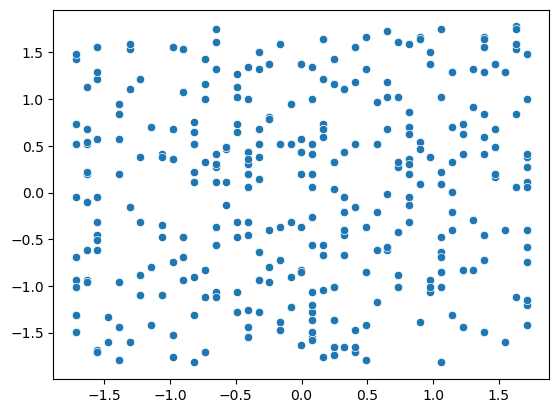

In [19]:
sns.scatterplot(x=X_train_scaled[:,0], y=X_train_scaled[:,1])

In [20]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


C:\Users\avraj\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6687 - loss: 0.6689 - val_accuracy: 0.7000 - val_loss: 0.6425
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7937 - loss: 0.6069 - val_accuracy: 0.7375 - val_loss: 0.5897
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8281 - loss: 0.5536 - val_accuracy: 0.7625 - val_loss: 0.5442
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8406 - loss: 0.5082 - val_accuracy: 0.8250 - val_loss: 0.5043
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8531 - loss: 0.4698 - val_accuracy: 0.8500 - val_loss: 0.4702
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8594 - loss: 0.4375 - val_accuracy: 0.8375 - val_loss: 0.4419
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8656 - loss: 0.4106 - val_accuracy: 0.8500 - val_loss: 0.4164
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8656 - loss: 0.3885 - val_accuracy: 0.8625 - val_loss: 0

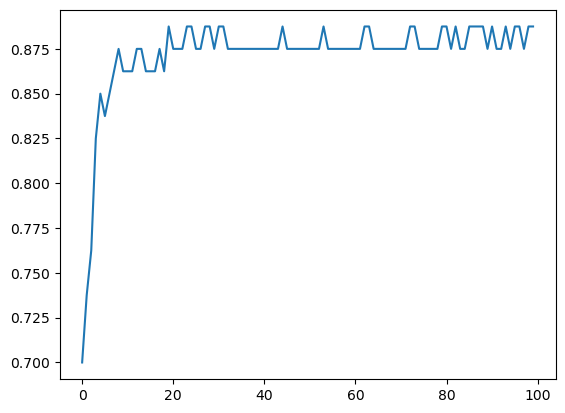

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])